# BMW Sales Data Analysis (2010–2024)
**Objective:** Analyze 14 years of BMW sales data to uncover regional trends,
pricing patterns, and the shift toward electric vehicles.

**Dataset:** BMW Sales Data 2010–2024 (source: Kaggle)
**Tools:** Python · Pandas · Matplotlib · Seaborn
**Author:** Sandip Subedi

In [2]:
# Import libraries
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

In [6]:
# load the data 
data = pd.read_csv("C:\\Users\\ASUS\\OneDrive\\Desktop\\DataScience\\projects_inst\\project_01\\BMW sales data (2010-2024) (1) (1).csv")

# print the shpae of the data 
print("The shape of the data :", data.shape)

# print top 5 data 
data.head()

The shape of the data : (50000, 11)


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [3]:
# Check the missing values 

missing_values = data.isnull().sum()

print("Missing data we have :")
missing_values 

Missing data we have :


Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64

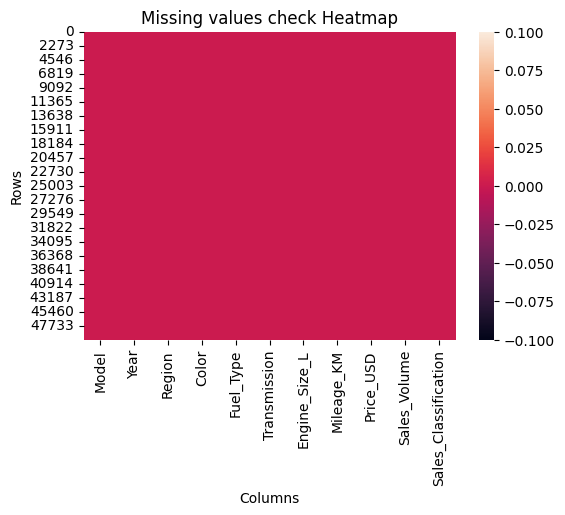

In [4]:
# missing data in heatmap 

plt.figure(figsize=(6,4))
sns.heatmap(data.isnull())
plt.title("Missing values check Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

## Data is totally clean as we checked 
- Missing values are seen 0 .
- No missing values are seen in heatmap 

so no need to clean any data can move forward to have visualization :

In [9]:
# Make a copy of original data for further work
data_work = data.copy()

print("Data copy created successfully. Shape:", data_work.shape)

Data copy created successfully. Shape: (50000, 11)


In [10]:
# Describe the data - Numeric columns
data_work.describe().round(2)

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.00,50000.00,50000.00,50000.00,50000.00
mean,2017.02,3.25,100307.20,75034.60,5067.51
std,4.32,1.01,57941.51,25998.25,2856.77
min,2010.00,1.50,3.00,30000.00,100.00
25%,2013.00,2.40,50178.00,52434.75,2588.00
50%,2017.00,3.20,100388.50,75011.50,5087.00
75%,2021.00,4.10,150630.25,97628.25,7537.25
max,2024.00,5.00,199996.00,119998.00,9999.00


In [11]:
# Describe the data - Categorical columns
data_work.describe(include="object")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12304\807147216.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data_work.describe(include="object")


,Model,Region,Color,Fuel_Type,Transmission,Sales_Classification
count,50000,50000,50000,50000,50000,50000
unique,11,6,6,4,2,2
top,7 Series,Asia,Red,Hybrid,Manual,Low
freq,4666,8454,8463,12716,25154,34754


## Value Counts & Charts of All Columns

**Note on chart types used:**
- **Bar chart** → for categorical columns (Model, Region, Color, Fuel_Type, Transmission, Sales_Classification)
- **Histogram** → for numeric columns (Engine_Size_L, Mileage_KM, Price_USD, Sales_Volume)
- **Line chart** → for Year (ordered over time)

In [12]:
# Value counts - Column : Model
value_count_model = data_work["Model"].value_counts()
value_count_model

Model
7 Series    4666
i3          4618
i8          4606
3 Series    4595
5 Series    4592
X1          4570
X3          4497
X5          4487
M5          4478
X6          4478
M3          4413
Name: count, dtype: int64

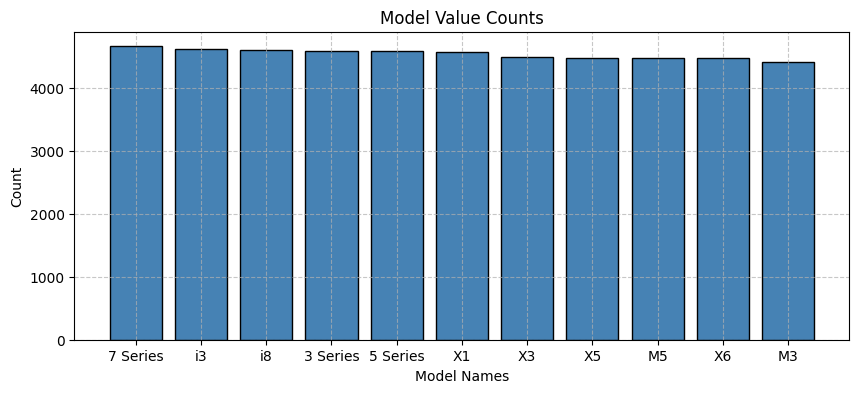

In [13]:
# Chart 1 : Model (bar chart - because Model is a category, not a number)

plt.figure(figsize=(10, 4))
plt.bar(value_count_model.index, value_count_model.values, color="steelblue", edgecolor="black")
plt.title("Model Value Counts")
plt.xlabel("Model Names")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [14]:
# Value counts - Column : Year
value_count_year = data_work["Year"].value_counts().sort_index()
value_count_year

Year
2010    3330
2011    3278
2012    3332
2013    3326
2014    3350
2015    3358
2016    3365
2017    3290
2018    3278
2019    3392
2020    3205
2021    3372
2022    3478
2023    3219
2024    3427
Name: count, dtype: int64

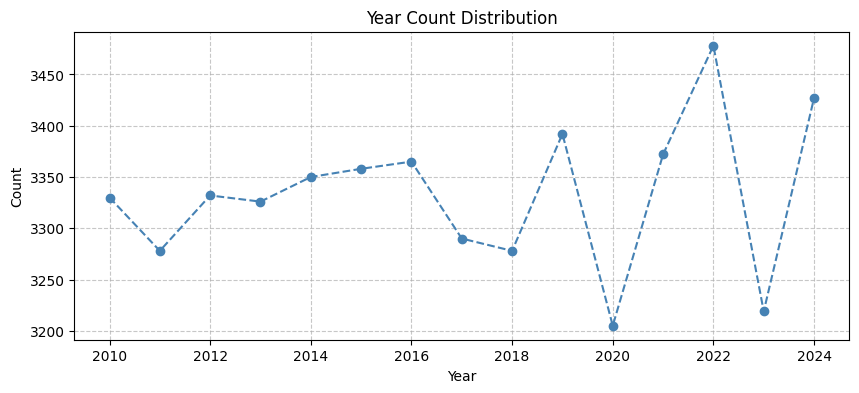

In [15]:
# Chart 2 : Year (line chart - because Year is ordered over time)

plt.figure(figsize=(10, 4))
plt.plot(value_count_year.index, value_count_year.values, marker="o", linestyle="--", color="steelblue")
plt.title("Year Count Distribution")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [16]:
# Value counts - Column : Region
value_count_Region = data_work["Region"].value_counts()
value_count_Region

Region
Asia             8454
Middle East      8373
North America    8335
Europe           8334
Africa           8253
South America    8251
Name: count, dtype: int64

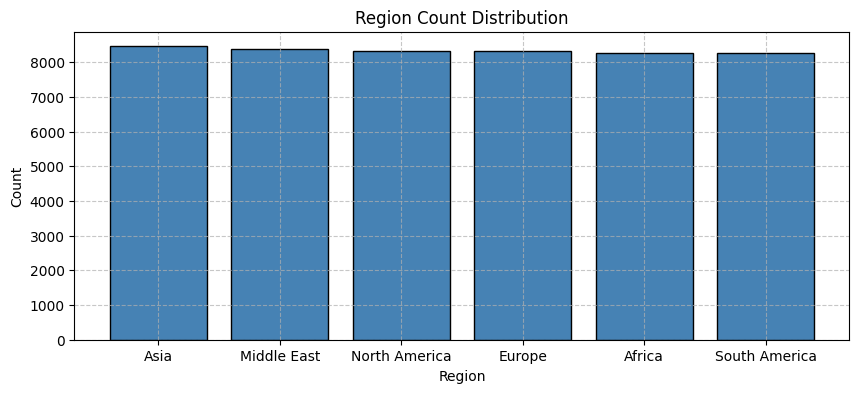

In [17]:
# Chart 3 : Region (bar chart - because Region is a category)

plt.figure(figsize=(10, 4))
plt.bar(value_count_Region.index, value_count_Region.values, color="steelblue", edgecolor="black")
plt.title("Region Count Distribution")
plt.xlabel("Region")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [18]:
# Value counts - Column : Color
value_count_Color = data_work["Color"].value_counts()
value_count_Color

Color
Red       8463
Silver    8350
Grey      8348
White     8304
Black     8273
Blue      8262
Name: count, dtype: int64

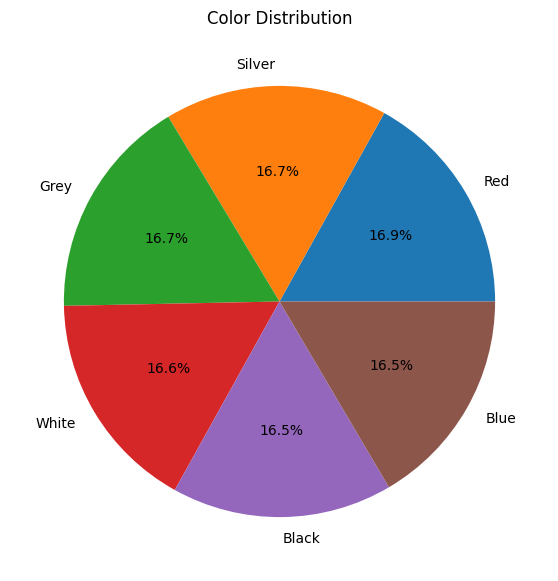

In [19]:
# Chart 4 : Color (pie chart - to show share of each color)

plt.figure(figsize=(7, 7))
plt.pie(value_count_Color.values, labels=value_count_Color.index, autopct="%1.1f%%")
plt.title("Color Distribution")
plt.show()

In [20]:
# Value counts - Column : Fuel_Type
value_count_Fuel_Type = data_work["Fuel_Type"].value_counts()
value_count_Fuel_Type

Fuel_Type
Hybrid      12716
Petrol      12550
Electric    12471
Diesel      12263
Name: count, dtype: int64

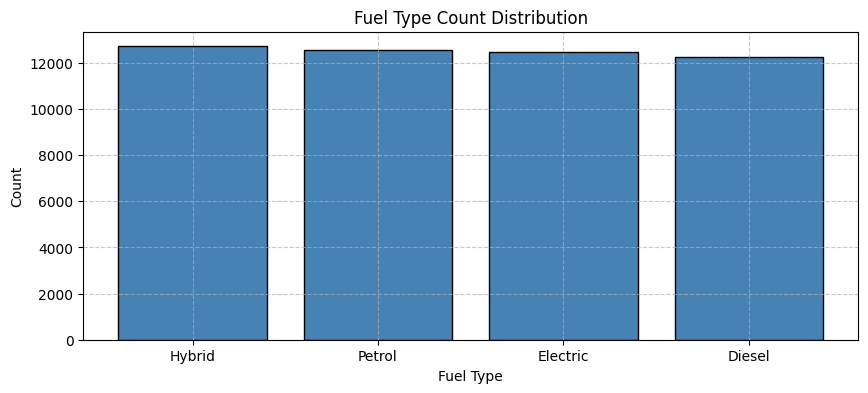

In [21]:
# Chart 5 : Fuel_Type (bar chart - because Fuel_Type is a category)

plt.figure(figsize=(10, 4))
plt.bar(value_count_Fuel_Type.index, value_count_Fuel_Type.values, color="steelblue", edgecolor="black")
plt.title("Fuel Type Count Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [22]:
# Value counts - Column : Transmission
value_count_Transmission = data_work["Transmission"].value_counts()
value_count_Transmission

Transmission
Manual       25154
Automatic    24846
Name: count, dtype: int64

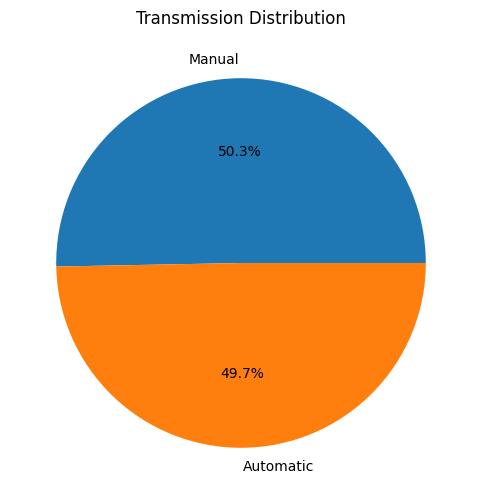

In [23]:
# Chart 6 : Transmission (pie chart)

plt.figure(figsize=(6, 6))
plt.pie(value_count_Transmission.values, labels=value_count_Transmission.index, autopct="%1.1f%%")
plt.title("Transmission Distribution")
plt.show()

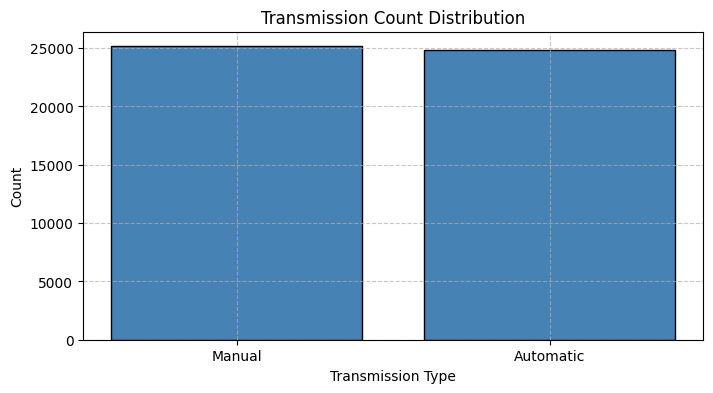

In [24]:
# Chart 7 : Transmission (bar chart)

plt.figure(figsize=(8, 4))
plt.bar(value_count_Transmission.index, value_count_Transmission.values, color="steelblue", edgecolor="black")
plt.title("Transmission Count Distribution")
plt.xlabel("Transmission Type")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

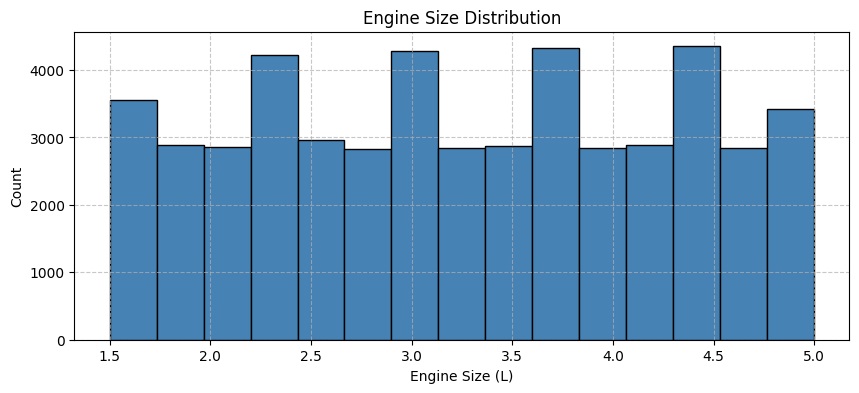

In [25]:
# Chart 8 : Engine_Size_L (histogram - because Engine_Size_L is numeric)
# A histogram shows how the values are distributed (spread), which bar/scatter cannot do properly

plt.figure(figsize=(10, 4))
plt.hist(data_work["Engine_Size_L"], bins=15, color="steelblue", edgecolor="black")
plt.title("Engine Size Distribution")
plt.xlabel("Engine Size (L)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

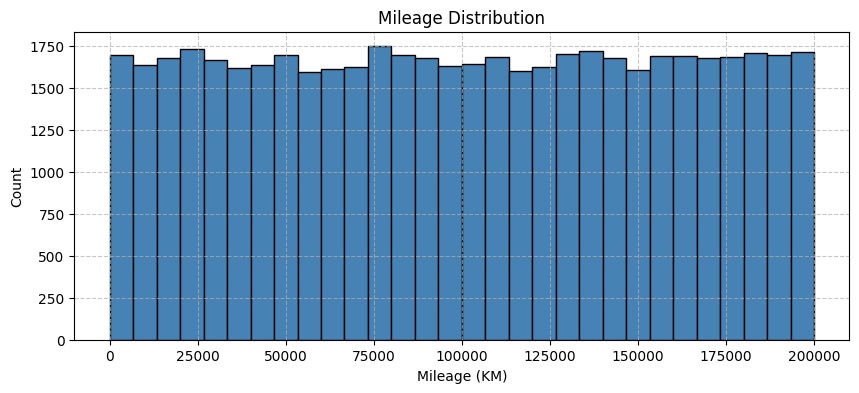

In [26]:
# Chart 9 : Mileage_KM (histogram - because Mileage_KM is numeric with many unique values)
# Using value_counts() on a numeric column with hundreds of unique values creates an unreadable chart

plt.figure(figsize=(10, 4))
plt.hist(data_work["Mileage_KM"], bins=30, color="steelblue", edgecolor="black")
plt.title("Mileage Distribution")
plt.xlabel("Mileage (KM)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

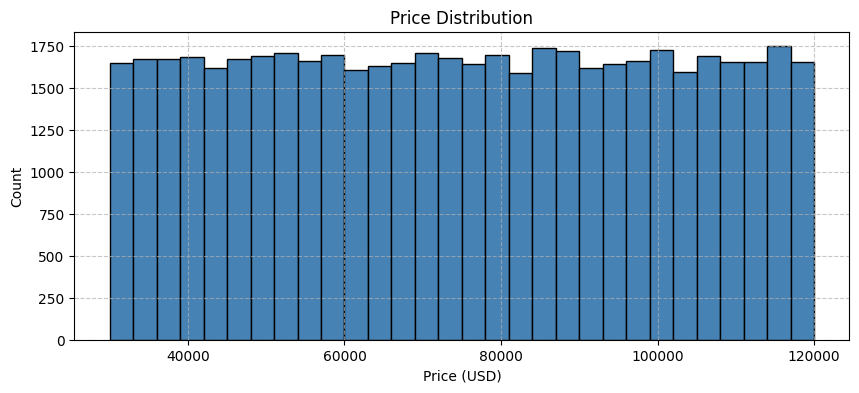

In [27]:
# Chart 10 : Price_USD (histogram - because Price_USD is numeric)

plt.figure(figsize=(10, 4))
plt.hist(data_work["Price_USD"], bins=30, color="steelblue", edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

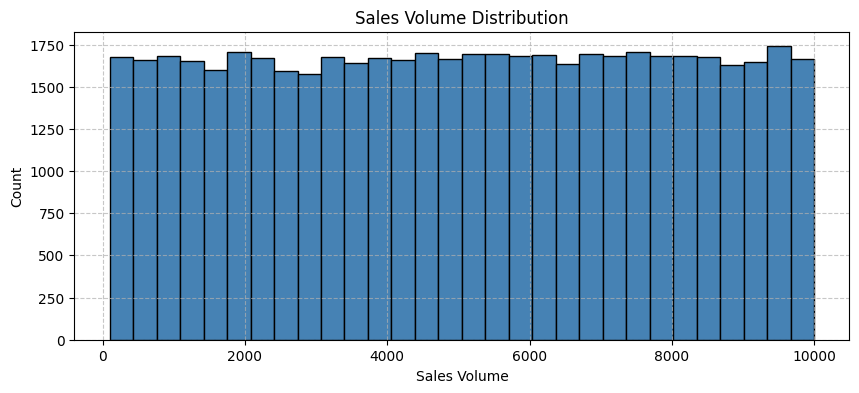

In [28]:
# Chart 11 : Sales_Volume (histogram - because Sales_Volume is numeric)

plt.figure(figsize=(10, 4))
plt.hist(data_work["Sales_Volume"], bins=30, color="steelblue", edgecolor="black")
plt.title("Sales Volume Distribution")
plt.xlabel("Sales Volume")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [29]:
# Value counts - Column : Sales_Classification
value_count_Sales_Classification = data_work["Sales_Classification"].value_counts()
value_count_Sales_Classification

Sales_Classification
Low     34754
High    15246
Name: count, dtype: int64

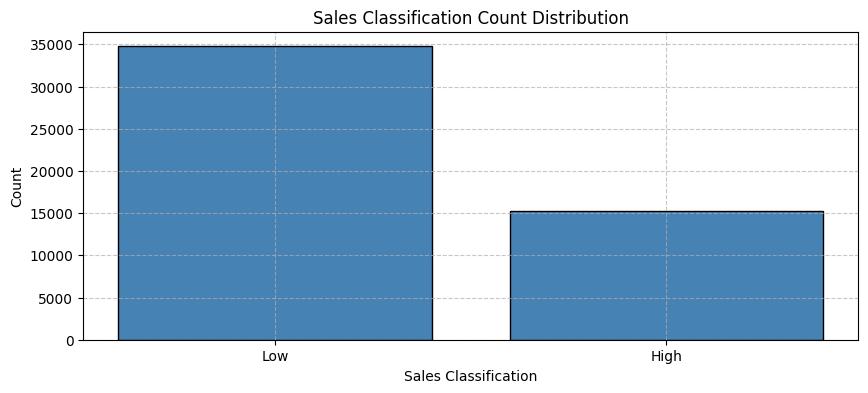

In [30]:
# Chart 12 : Sales_Classification (bar chart - because Sales_Classification is a category)

plt.figure(figsize=(10, 4))
plt.bar(value_count_Sales_Classification.index, value_count_Sales_Classification.values, color="steelblue", edgecolor="black")
plt.title("Sales Classification Count Distribution")
plt.xlabel("Sales Classification")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

## Correlation Heatmap

A correlation heatmap shows how numeric columns relate to each other.
- Values close to **1** mean strong positive relationship
- Values close to **-1** mean strong negative relationship
- Values close to **0** mean no relationship

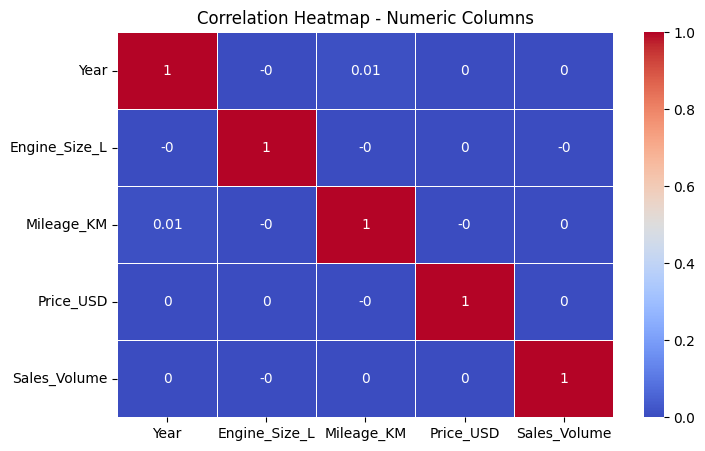

In [31]:
# Correlation Heatmap - numeric columns only

plt.figure(figsize=(8, 5))
sns.heatmap(data_work.select_dtypes(include="number").corr().round(2),
            annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap - Numeric Columns")
plt.show()

## Groupby Analysis

Here we group the data by key columns and calculate the mean to find patterns.

In [32]:
# Groupby 01 : Region by Average Price_USD
Price_cla__data = data_work.groupby("Region")["Price_USD"].mean().round(2)
Price_cla__data

Region
Africa           74885.77
Asia             75554.93
Europe           74988.36
Middle East      74726.79
North America    75070.05
South America    74973.60
Name: Price_USD, dtype: float64

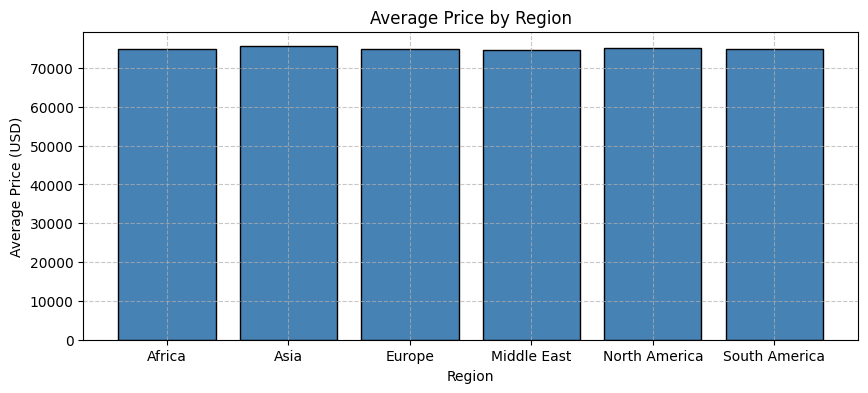

In [33]:
# Groupby 01 : Region by Average Price_USD
# Chart 1 : Bar chart

plt.figure(figsize=(10, 4))
plt.bar(Price_cla__data.index, Price_cla__data.values, color="steelblue", edgecolor="black")
plt.title("Average Price by Region")
plt.xlabel("Region")
plt.ylabel("Average Price (USD)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

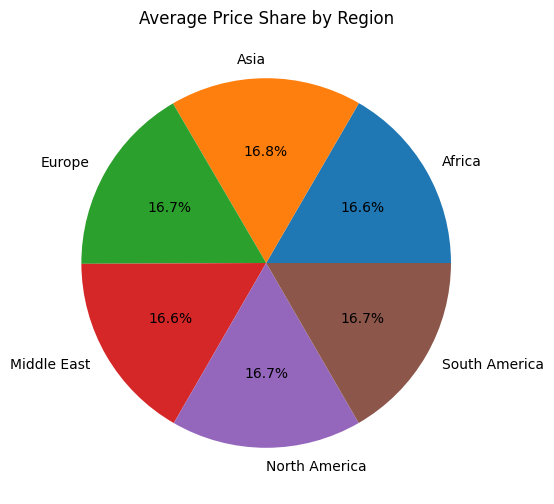

In [34]:
# Groupby 01 : Region by Average Price_USD
# Chart 2 : Pie chart

plt.figure(figsize=(6, 6))
plt.pie(Price_cla__data.values, labels=Price_cla__data.index, autopct="%1.1f%%")
plt.title("Average Price Share by Region")
plt.show()

In [35]:
# Groupby 02 : Sales Classification by Average Engine_Size_L
sales_cla__data = data_work.groupby("Sales_Classification")["Engine_Size_L"].mean().round(2)
sales_cla__data

Sales_Classification
High    3.24
Low     3.25
Name: Engine_Size_L, dtype: float64

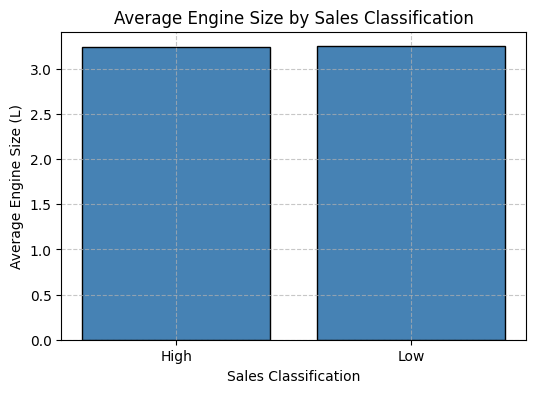

In [36]:
# Groupby 02 : Sales Classification by Average Engine_Size_L
# Chart 1 : Bar chart

plt.figure(figsize=(6, 4))
plt.bar(sales_cla__data.index, sales_cla__data.values, color="steelblue", edgecolor="black")
plt.title("Average Engine Size by Sales Classification")
plt.xlabel("Sales Classification")
plt.ylabel("Average Engine Size (L)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

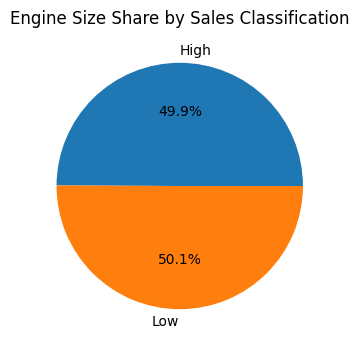

In [37]:
# Groupby 02 : Sales Classification by Average Engine_Size_L
# Chart 2 : Pie chart

plt.figure(figsize=(6, 4))
plt.pie(sales_cla__data.values, labels=sales_cla__data.index, autopct="%1.1f%%")
plt.title("Engine Size Share by Sales Classification")
plt.show()

In [38]:
# Groupby 03 : Model by Average Sales_Volume
Model_cla__data = data_work.groupby("Model")["Sales_Volume"].mean().round(2)
Model_cla__data

Model
3 Series    5066.66
5 Series    5029.95
7 Series    5097.83
M3          5064.51
M5          5087.02
X1          5121.68
X3          5057.93
X5          5061.23
X6          5060.74
i3          5009.50
i8          5085.52
Name: Sales_Volume, dtype: float64

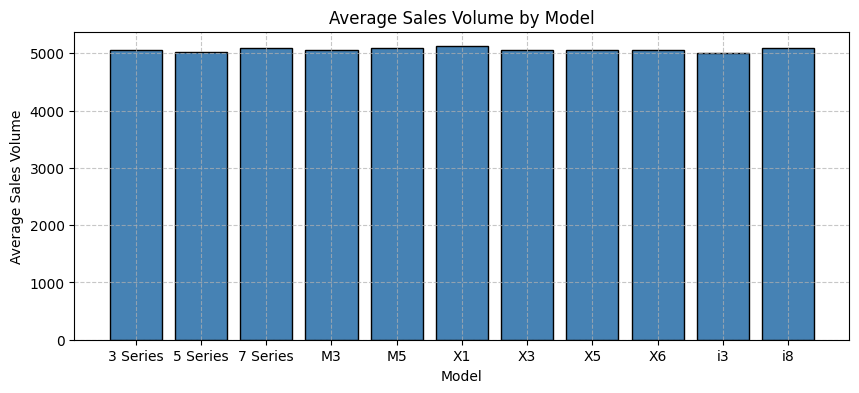

In [39]:
# Groupby 03 : Model by Average Sales_Volume
# Chart 1 : Bar chart

plt.figure(figsize=(10, 4))
plt.bar(Model_cla__data.index, Model_cla__data.values, color="steelblue", edgecolor="black")
plt.title("Average Sales Volume by Model")
plt.xlabel("Model")
plt.ylabel("Average Sales Volume")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

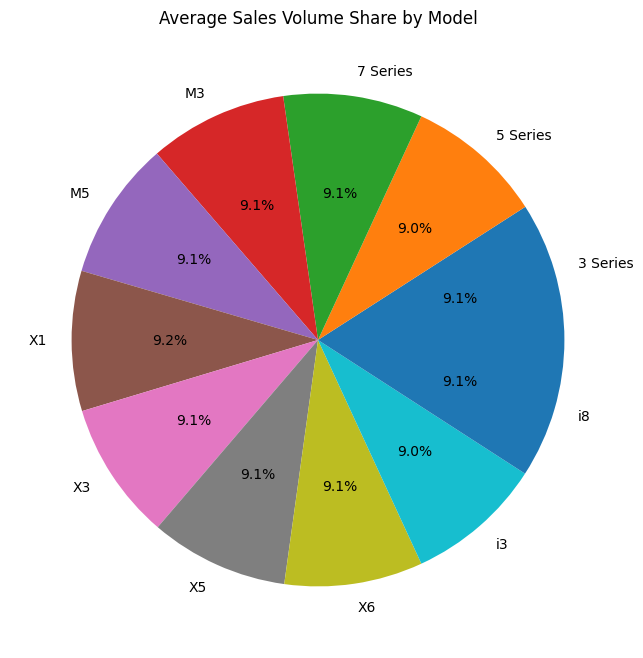

In [40]:
# Groupby 03 : Model by Average Sales_Volume
# Chart 2 : Pie chart

plt.figure(figsize=(8, 8))
plt.pie(Model_cla__data.values, labels=Model_cla__data.index, autopct="%1.1f%%")
plt.title("Average Sales Volume Share by Model")
plt.show()

In [41]:
# Groupby 04 : Region by Average Sales_Volume
Region_cla__data = data_work.groupby("Region")["Sales_Volume"].mean().round(2)
Region_cla__data

Region
Africa           5036.38
Asia             5083.31
Europe           5106.21
Middle East      5055.13
North America    5087.30
South America    5035.97
Name: Sales_Volume, dtype: float64

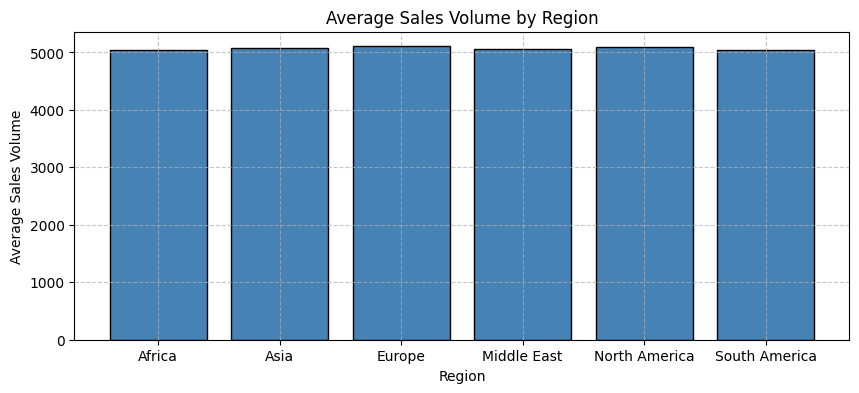

In [42]:
# Groupby 04 : Region by Average Sales_Volume
# Chart 1 : Bar chart

plt.figure(figsize=(10, 4))
plt.bar(Region_cla__data.index, Region_cla__data.values, color="steelblue", edgecolor="black")
plt.title("Average Sales Volume by Region")
plt.xlabel("Region")
plt.ylabel("Average Sales Volume")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

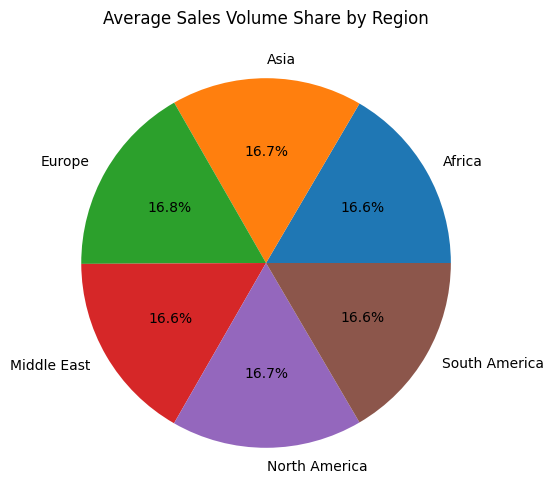

In [43]:
# Groupby 04 : Region by Average Sales_Volume
# Chart 2 : Pie chart

plt.figure(figsize=(6, 6))
plt.pie(Region_cla__data.values, labels=Region_cla__data.index, autopct="%1.1f%%")
plt.title("Average Sales Volume Share by Region")
plt.show()

In [44]:
# Groupby 05 : Fuel_Type by Average Engine_Size_L
fueltype_cla_data = data_work.groupby("Fuel_Type")["Engine_Size_L"].mean().round(2)
fueltype_cla_data

Fuel_Type
Diesel      3.25
Electric    3.24
Hybrid      3.25
Petrol      3.25
Name: Engine_Size_L, dtype: float64

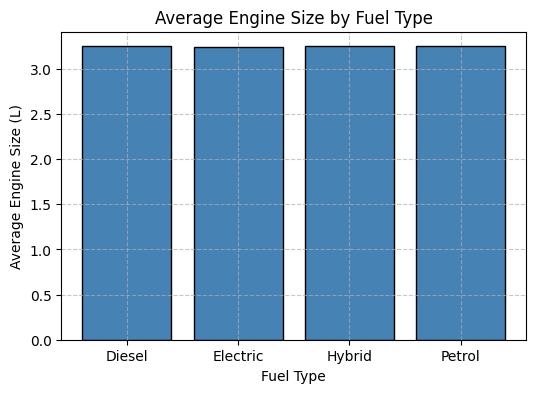

In [45]:
# Groupby 05 : Fuel_Type by Average Engine_Size_L
# Chart 1 : Bar chart

plt.figure(figsize=(6, 4))
plt.bar(fueltype_cla_data.index, fueltype_cla_data.values, color="steelblue", edgecolor="black")
plt.title("Average Engine Size by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Engine Size (L)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

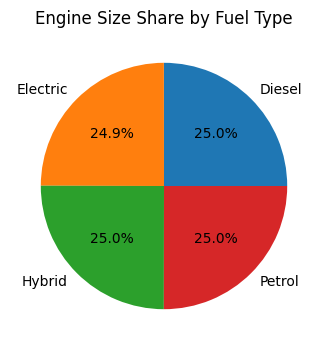

In [46]:
# Groupby 05 : Fuel_Type by Average Engine_Size_L
# Chart 2 : Pie chart

plt.figure(figsize=(6, 4))
plt.pie(fueltype_cla_data.values, labels=fueltype_cla_data.index, autopct="%1.1f%%")
plt.title("Engine Size Share by Fuel Type")
plt.show()

In [47]:
# Groupby 06 : Transmission by Average Price_USD
Transmission_cla_data = data_work.groupby("Transmission")["Price_USD"].mean().round(2)
Transmission_cla_data

Transmission
Automatic    75171.41
Manual       74899.47
Name: Price_USD, dtype: float64

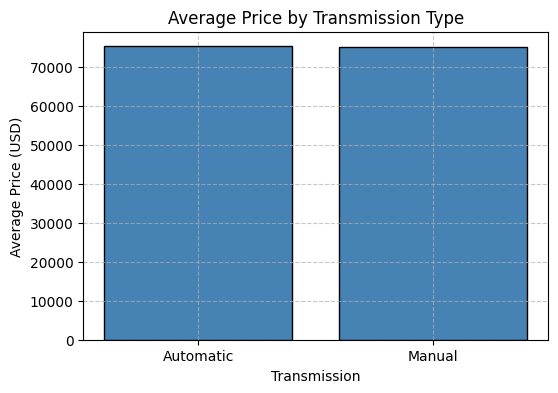

In [48]:
# Groupby 06 : Transmission by Average Price_USD
# Chart 1 : Bar chart

plt.figure(figsize=(6, 4))
plt.bar(Transmission_cla_data.index, Transmission_cla_data.values, color="steelblue", edgecolor="black")
plt.title("Average Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Average Price (USD)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

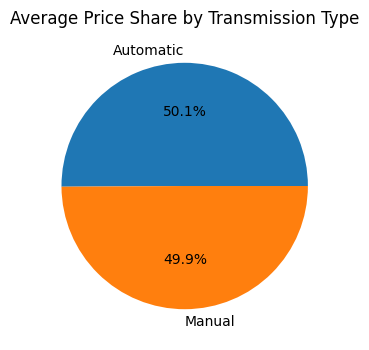

In [49]:
# Groupby 06 : Transmission by Average Price_USD
# Chart 2 : Pie chart

plt.figure(figsize=(6, 4))
plt.pie(Transmission_cla_data.values, labels=Transmission_cla_data.index, autopct="%1.1f%%")
plt.title("Average Price Share by Transmission Type")
plt.show()

In [50]:
# Groupby 07 : Year by Average Sales_Volume
sales_by_year_data = data_work.groupby("Year")["Sales_Volume"].mean().round(2)
sales_by_year_data

Year
2010    5085.12
2011    5112.55
2012    5027.58
2013    5071.18
2014    5062.38
2015    5065.58
2016    5039.39
2017    5051.92
2018    5006.79
2019    5068.38
2020    5089.19
2021    5007.31
2022    5152.66
2023    5053.95
2024    5114.63
Name: Sales_Volume, dtype: float64

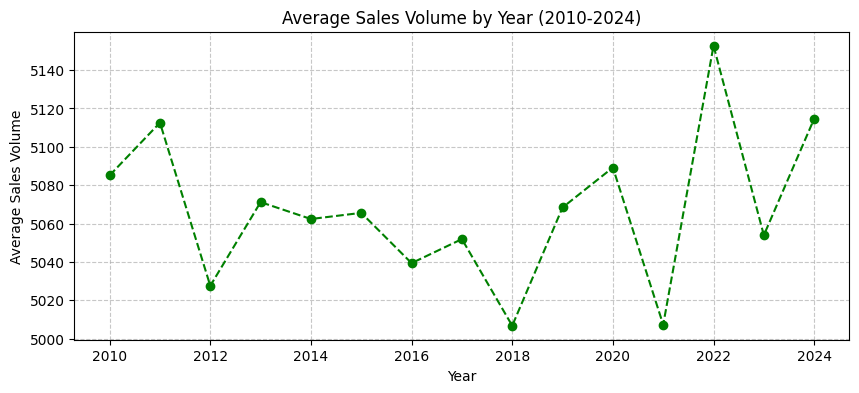

In [51]:
# Groupby 07 : Year by Average Sales_Volume
# Chart 1 : Line chart (Year is ordered over time, so line chart is correct here)

plt.figure(figsize=(10, 4))
plt.plot(sales_by_year_data.index, sales_by_year_data.values, marker="o", linestyle="--", color="green")
plt.title("Average Sales Volume by Year (2010-2024)")
plt.xlabel("Year")
plt.ylabel("Average Sales Volume")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

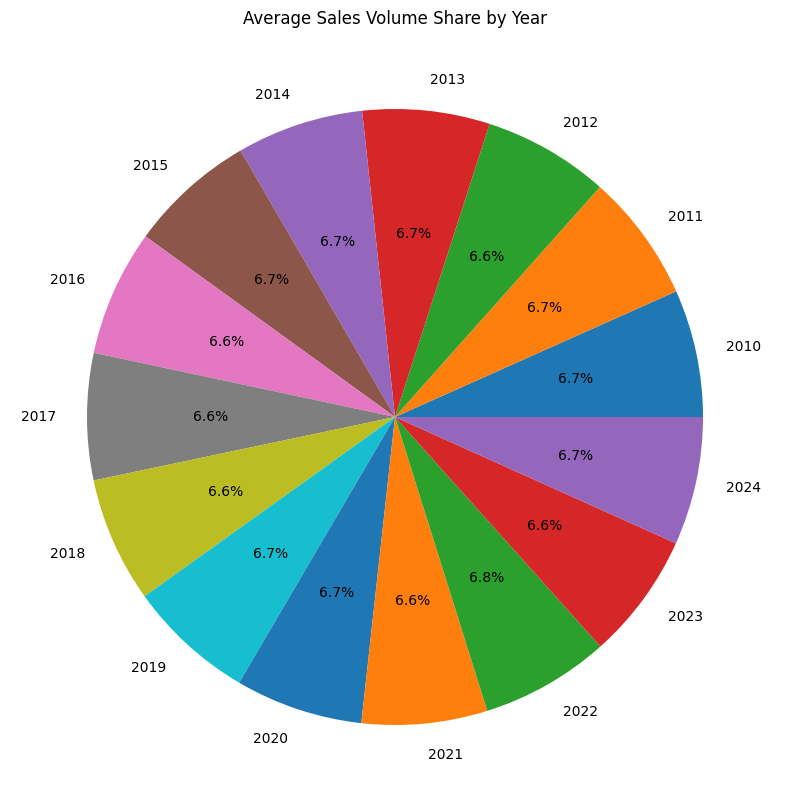

In [52]:
# Groupby 07 : Year by Average Sales_Volume
# Chart 2 : Pie chart

plt.figure(figsize=(10, 10))
plt.pie(sales_by_year_data.values, labels=sales_by_year_data.index, autopct="%1.1f%%")
plt.title("Average Sales Volume Share by Year")
plt.show()

In [53]:
# Groupby 08 : Sales_Classification by Average Sales_Volume
sales_data = data_work.groupby("Sales_Classification")["Sales_Volume"].mean().round(2)
sales_data

Sales_Classification
High    8497.50
Low     3562.84
Name: Sales_Volume, dtype: float64

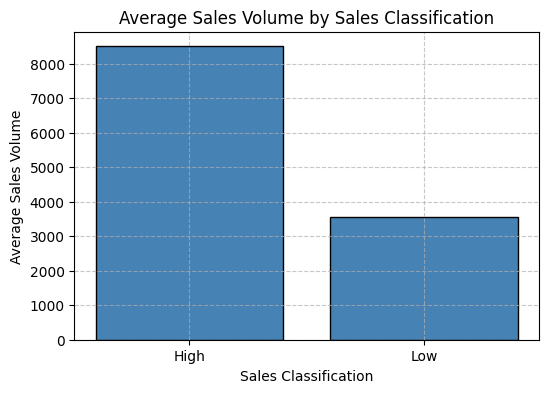

In [54]:
# Groupby 08 : Sales_Classification by Average Sales_Volume
# Chart 1 : Bar chart

plt.figure(figsize=(6, 4))
plt.bar(sales_data.index, sales_data.values, color="steelblue", edgecolor="black")
plt.title("Average Sales Volume by Sales Classification")
plt.xlabel("Sales Classification")
plt.ylabel("Average Sales Volume")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

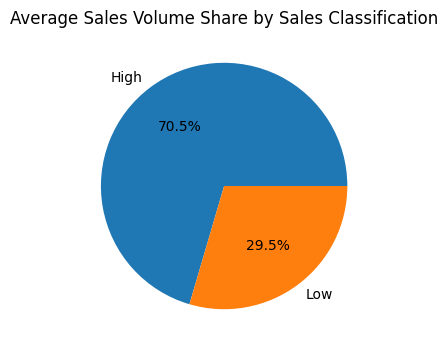

In [55]:
# Groupby 08 : Sales_Classification by Average Sales_Volume
# Chart 2 : Pie chart

plt.figure(figsize=(6, 4))
plt.pie(sales_data.values, labels=sales_data.index, autopct="%1.1f%%")
plt.title("Average Sales Volume Share by Sales Classification")
plt.show()

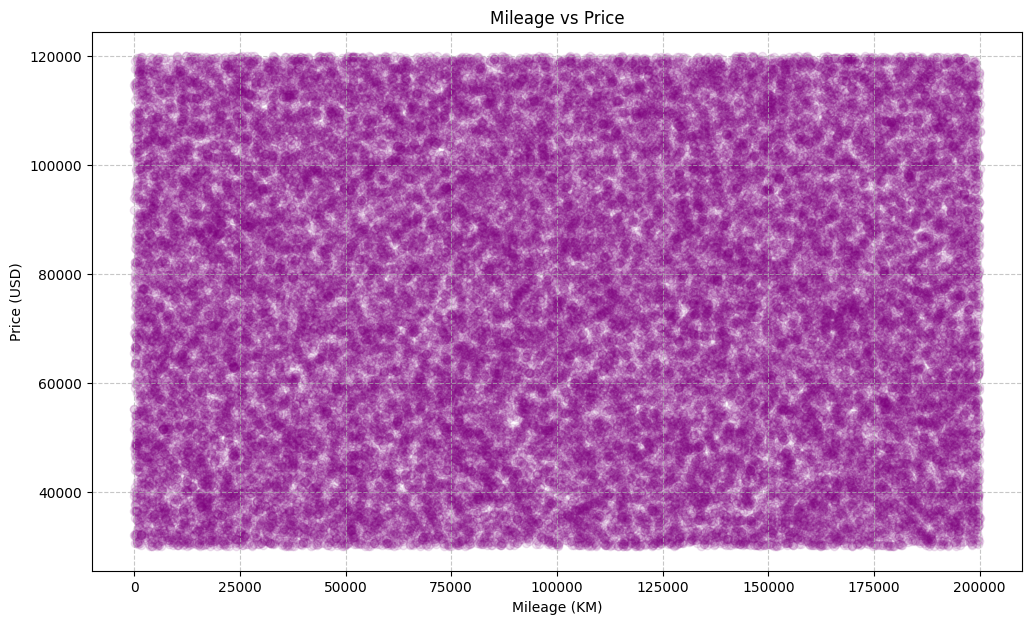

In [56]:
# Scatter : Mileage vs Price_USD
# Scatter chart is used here because both columns are numeric - we want to see the relationship between them

plt.figure(figsize=(12, 7))
plt.scatter(data_work["Mileage_KM"], data_work["Price_USD"], alpha=0.1, color="purple")
plt.title("Mileage vs Price")
plt.xlabel("Mileage (KM)")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

<Figure size 1200x600 with 0 Axes>

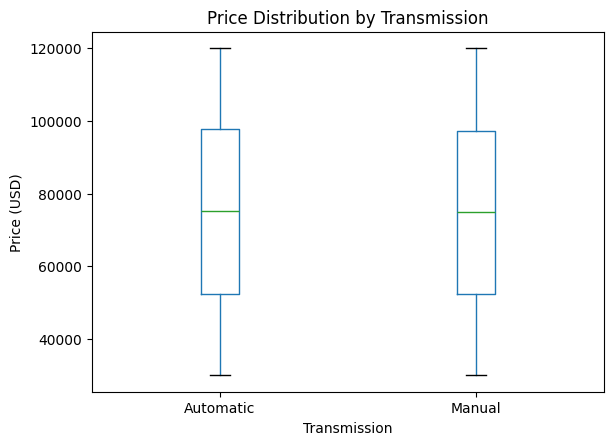

In [57]:
# Boxplot : Price Distribution by Transmission
# Boxplot shows the spread and outliers of Price for each Transmission type

plt.figure(figsize=(12, 6))
data_work.boxplot(column="Price_USD", by="Transmission", grid=False)
plt.title("Price Distribution by Transmission")
plt.suptitle("")   # removes the default pandas title
plt.xlabel("Transmission")
plt.ylabel("Price (USD)")
plt.show()

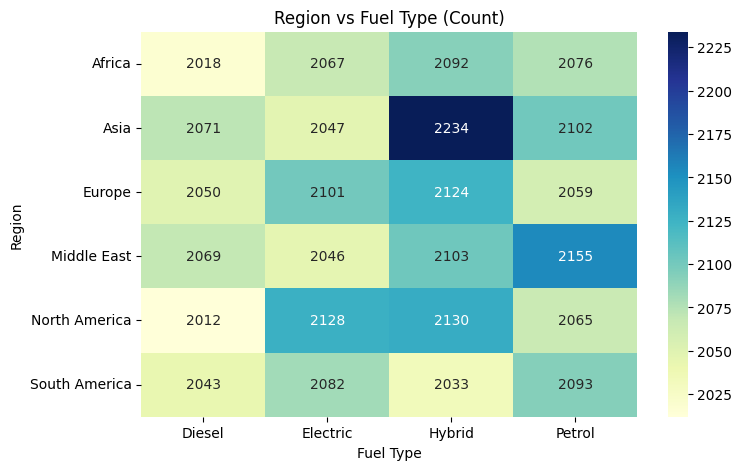

In [58]:
# Heatmap : Region vs Fuel Type (count)
# Crosstab counts how many times each Region + Fuel_Type combination appears

ct_region_fuel = pd.crosstab(data_work["Region"], data_work["Fuel_Type"])

plt.figure(figsize=(8, 5))
sns.heatmap(ct_region_fuel, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Region vs Fuel Type (Count)")
plt.xlabel("Fuel Type")
plt.ylabel("Region")
plt.show()

## Final Dashboard & Summary Report

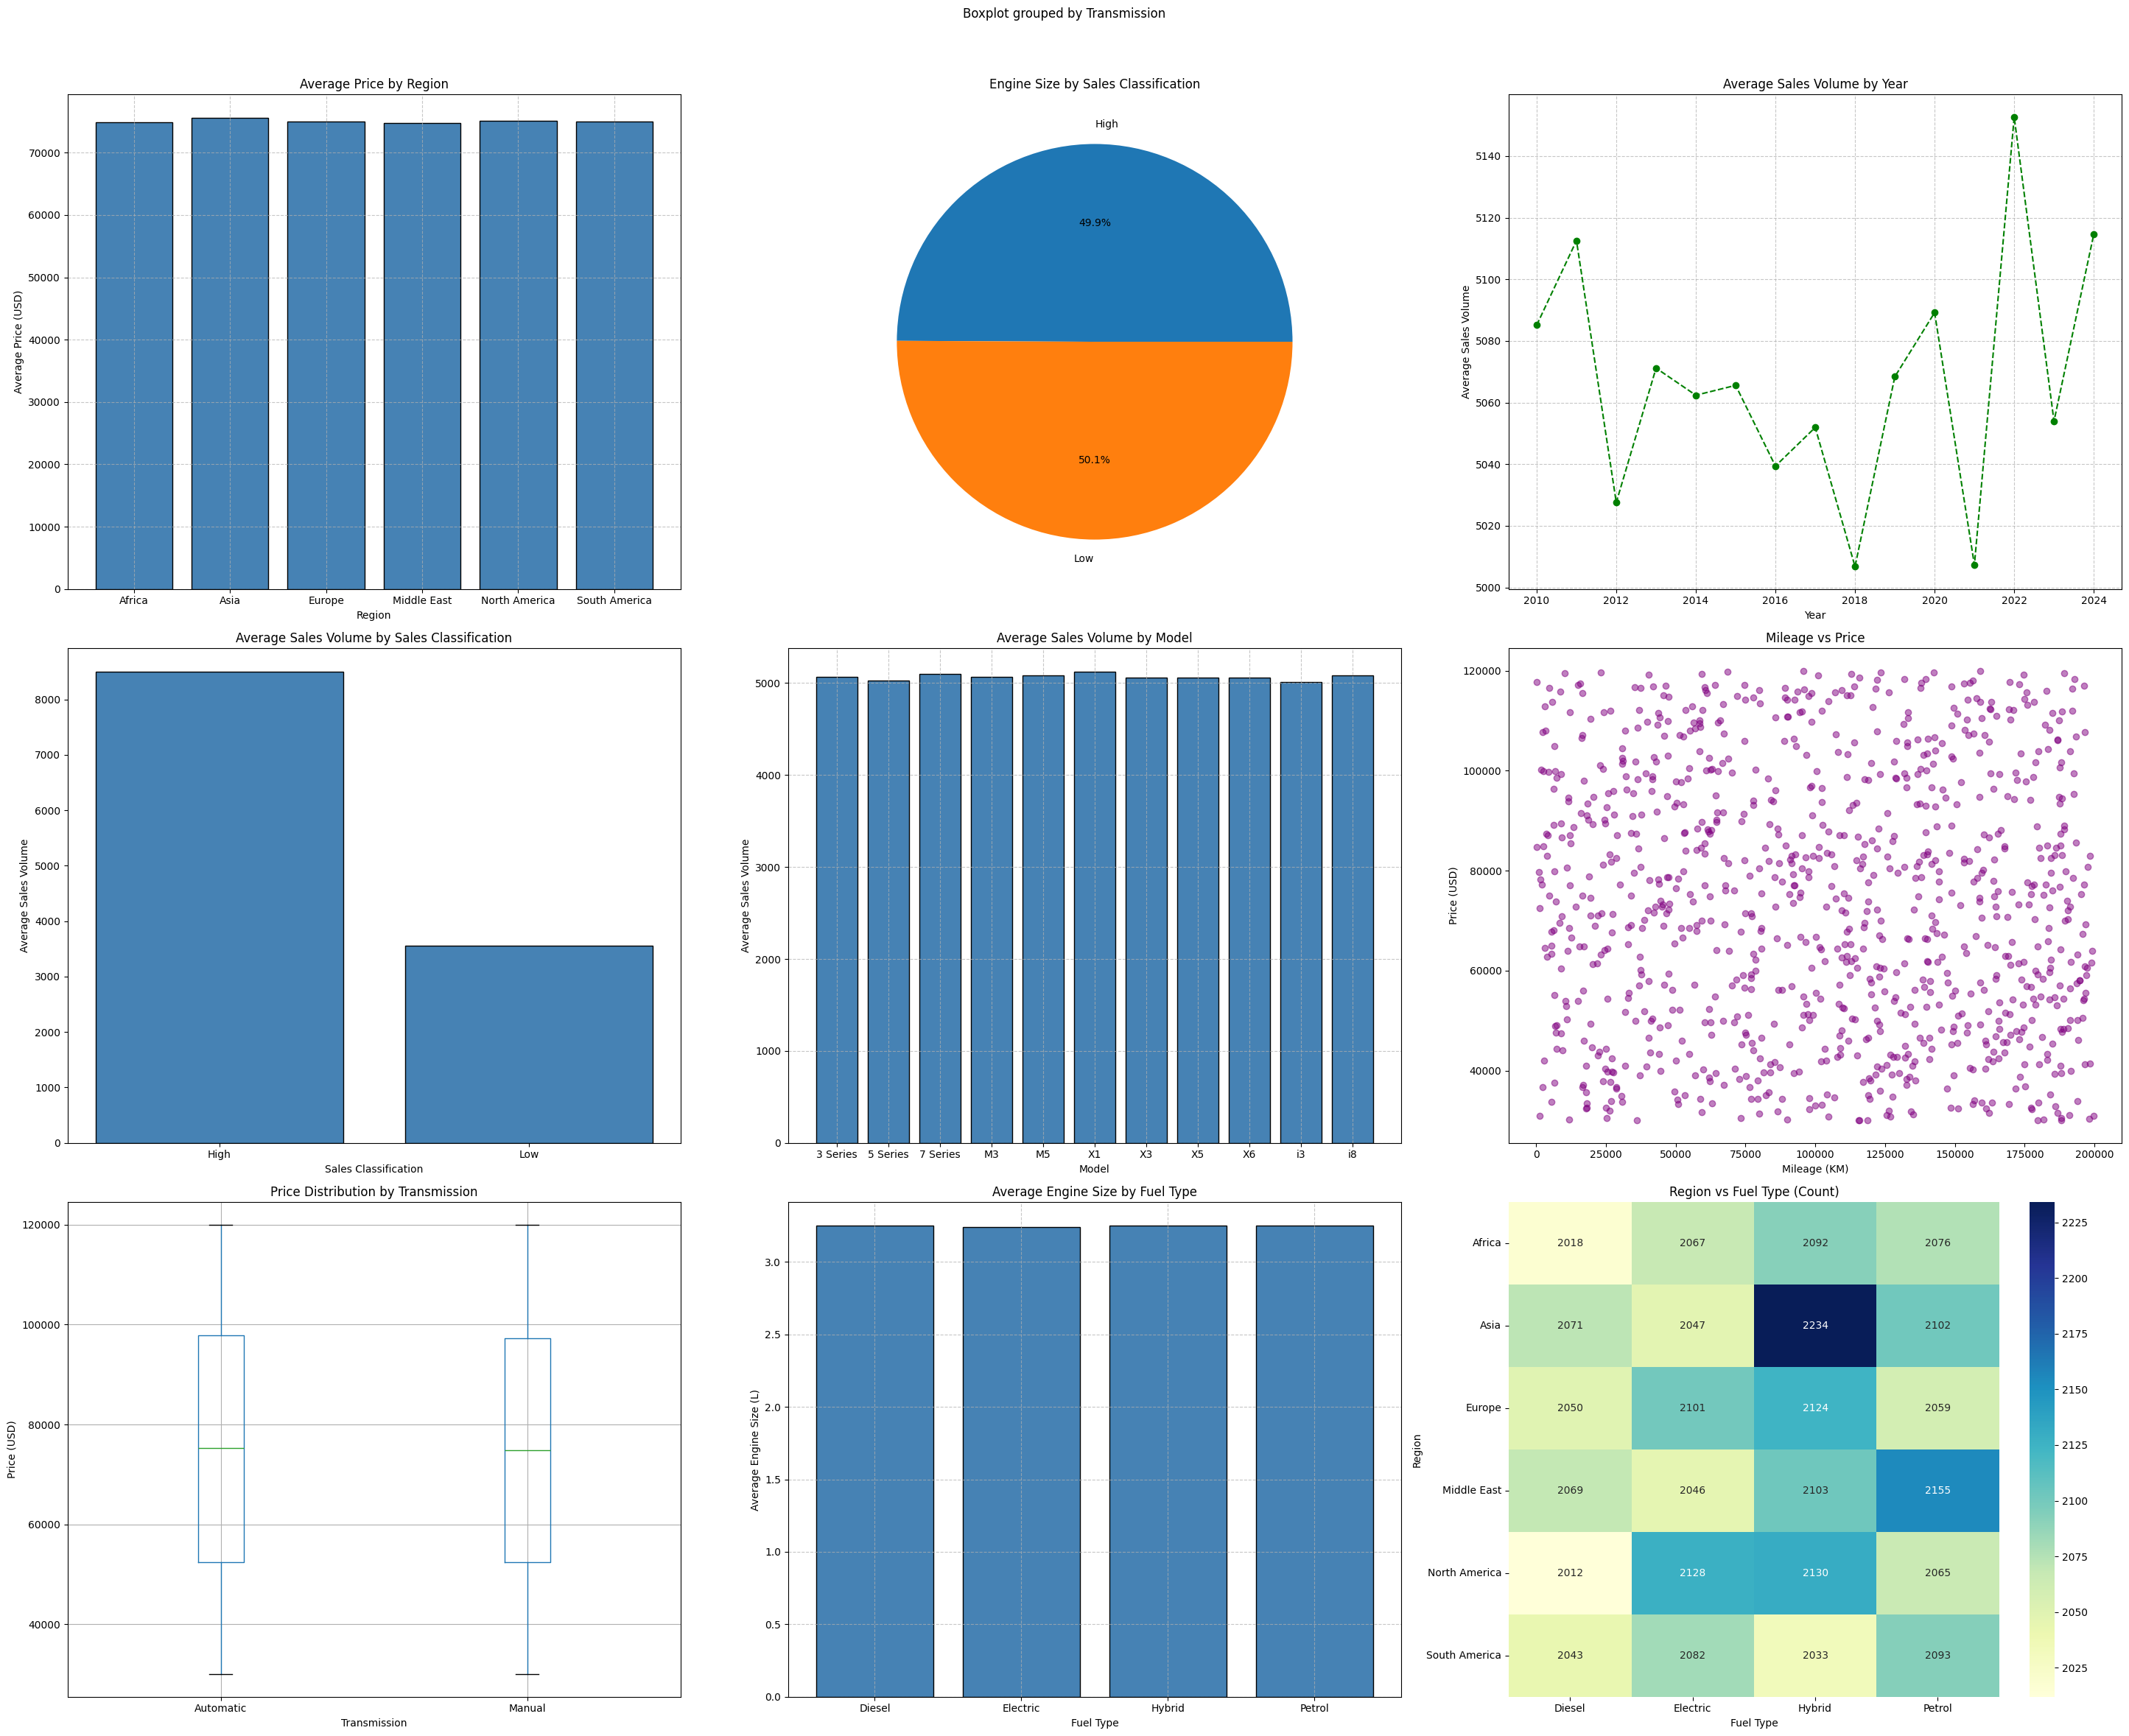

          BMW DATA SCIENCE ANALYSIS REPORT
REPORT SCOPE:       2010 - 2024
TOTAL RECORDS:      50,000 Units Analyzed
------------------------------------------------------------
1. FINANCIALS:      Average Sale Price is $75,034.60
2. TOP PERFORMER:   The '7 Series' is the most frequent model in stock.
3. MARKET LEADER:   'Asia' is the highest performing sales region.
4. EV ADOPTION:     Electric vehicles make up 24.9% of inventory.
------------------------------------------------------------
CRITICAL INSIGHTS:
- Sales volume shows a stable trend over the 14-year period.
- Pricing is evenly distributed, suggesting BMW maintains a consistent
  presence across both Entry-level Luxury and High-end Luxury tiers.
- The scatter plot shows Price does not significantly restrict Sales Volume.


In [59]:
# ------------------------------------------------
# 1. Data Analysis Calculations
# ------------------------------------------------

total_record        = len(data)
avg_price           = data["Price_USD"].mean()
total_sales_volume  = data["Sales_Volume"].sum()
top_model           = data["Model"].value_counts().idxmax()
best_region         = data.groupby("Region")["Sales_Volume"].sum().idxmax()
electric_percentage = (len(data[data["Fuel_Type"] == "Electric"]) / total_record) * 100


# ------------------------------------------------
# 2. Final Visual Dashboard (3x3 grid)
# ------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(29, 24))
fig.suptitle("BMW DATA ANALYSIS REPORT (2010-2024)", fontsize=20, fontweight="bold")


# Chart 1 : Average Price by Region
axes[0, 0].bar(Price_cla__data.index, Price_cla__data.values, color="steelblue", edgecolor="black")
axes[0, 0].set_title("Average Price by Region")
axes[0, 0].set_xlabel("Region")
axes[0, 0].set_ylabel("Average Price (USD)")
axes[0, 0].grid(True, linestyle="--", alpha=0.7)


# Chart 2 : Engine Size Share by Sales Classification
axes[0, 1].pie(sales_cla__data.values, labels=sales_cla__data.index, autopct="%1.1f%%")
axes[0, 1].set_title("Engine Size by Sales Classification")


# Chart 3 : Sales Volume Trend by Year (line chart - year is time ordered)
axes[0, 2].plot(sales_by_year_data.index, sales_by_year_data.values, marker="o", linestyle="--", color="green")
axes[0, 2].set_title("Average Sales Volume by Year")
axes[0, 2].set_xlabel("Year")
axes[0, 2].set_ylabel("Average Sales Volume")
axes[0, 2].grid(True, linestyle="--", alpha=0.7)


# Chart 4 : Average Sales Volume by Sales Classification
axes[1, 0].bar(sales_data.index, sales_data.values, color="steelblue", edgecolor="black")
axes[1, 0].set_title("Average Sales Volume by Sales Classification")
axes[1, 0].set_xlabel("Sales Classification")
axes[1, 0].set_ylabel("Average Sales Volume")


# Chart 5 : Average Sales Volume by Model
axes[1, 1].bar(Model_cla__data.index, Model_cla__data.values, color="steelblue", edgecolor="black")
axes[1, 1].set_title("Average Sales Volume by Model")
axes[1, 1].set_xlabel("Model")
axes[1, 1].set_ylabel("Average Sales Volume")
axes[1, 1].grid(True, linestyle="--", alpha=0.7)


# Chart 6 : Mileage vs Price (scatter - sample 1000 for performance)
sample_data = data_work.sample(1000, random_state=42)
axes[1, 2].scatter(sample_data["Mileage_KM"], sample_data["Price_USD"], alpha=0.5, color="purple")
axes[1, 2].set_title("Mileage vs Price")
axes[1, 2].set_xlabel("Mileage (KM)")
axes[1, 2].set_ylabel("Price (USD)")


# Chart 7 : Price Distribution by Transmission (boxplot)
data_work.boxplot(column="Price_USD", by="Transmission", ax=axes[2, 0], grid=True)
axes[2, 0].set_title("Price Distribution by Transmission")
axes[2, 0].set_xlabel("Transmission")
axes[2, 0].set_ylabel("Price (USD)")


# Chart 8 : Average Engine Size by Fuel Type
axes[2, 1].bar(fueltype_cla_data.index, fueltype_cla_data.values, color="steelblue", edgecolor="black")
axes[2, 1].set_title("Average Engine Size by Fuel Type")
axes[2, 1].set_xlabel("Fuel Type")
axes[2, 1].set_ylabel("Average Engine Size (L)")
axes[2, 1].grid(True, linestyle="--", alpha=0.7)


# Chart 9 : Region vs Fuel Type Heatmap
# IMPORTANT: we pass ax=axes[2,2] so seaborn draws on the correct subplot
ct_region_fuel = pd.crosstab(data_work["Region"], data_work["Fuel_Type"])
sns.heatmap(ct_region_fuel, annot=True, fmt="d", cmap="YlGnBu", ax=axes[2, 2])
axes[2, 2].set_title("Region vs Fuel Type (Count)")
axes[2, 2].set_xlabel("Fuel Type")
axes[2, 2].set_ylabel("Region")


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# -------------------------------------------------
# 3. SUMMARY OF THE PROJECT
# -------------------------------------------------
print("=" * 60)
print("          BMW DATA SCIENCE ANALYSIS REPORT")
print("=" * 60)
print(f"REPORT SCOPE:       2010 - 2024")
print(f"TOTAL RECORDS:      {total_record:,} Units Analyzed")
print("-" * 60)
print(f"1. FINANCIALS:      Average Sale Price is ${avg_price:,.2f}")
print(f"2. TOP PERFORMER:   The '{top_model}' is the most frequent model in stock.")
print(f"3. MARKET LEADER:   '{best_region}' is the highest performing sales region.")
print(f"4. EV ADOPTION:     Electric vehicles make up {electric_percentage:.1f}% of inventory.")
print("-" * 60)
print("CRITICAL INSIGHTS:")
print(f"- Sales volume shows a stable trend over the 14-year period.")
print(f"- Pricing is evenly distributed, suggesting BMW maintains a consistent")
print(f"  presence across both Entry-level Luxury and High-end Luxury tiers.")
print(f"- The scatter plot shows Price does not significantly restrict Sales Volume.")
print("=" * 60)